In [1]:
from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.study_locus import StudyLocus
from gentropy.dataset.variant_index import VariantIndex
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment
from pyspark.sql import functions as f


Loading BokehJS ...

/Users/yt4/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/25 11:31:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "../../../data/25.06/"
path_to_intermediate_data_folder = "../../../data/intermediate_files/"

sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set")
si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study")

sl_eff = session.spark.read.parquet(path_to_intermediate_data_folder + "lead_variant_effect")

l2g_full = session.spark.read.parquet(
    path_to_intermediate_data_folder + "list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet"
)


In [ ]:
coloc = session.spark.read.parquet(path_to_release_folder + "/output/colocalisation_coloc")
ecaviar = session.spark.read.parquet(path_to_release_folder + "/output/colocalisation_ecaviar")


# Calculating temporal vPS


In [7]:
def cluster_lead_variants(lead_variants_list, colocalisation_list):
    # Create a lookup for studyLocusId to the full data dictionary
    study_locus_info = {item["studyLocusId"]: item for item in lead_variants_list}

    # Create a lookup from variantId to a list of studyLocusIds
    variant_to_loci = {}
    for item in lead_variants_list:
        variant_id = item["leadVariantId"]
        if variant_id not in variant_to_loci:
            variant_to_loci[variant_id] = []
        variant_to_loci[variant_id].append(item["studyLocusId"])

    # Create a lookup for colocalisation
    coloc_lookup = {}
    for item in colocalisation_list:
        left_id = item["leftStudyLocusId"]
        right_id = item["rightStudyLocusId"]
        if left_id not in coloc_lookup:
            coloc_lookup[left_id] = set()
        if right_id not in coloc_lookup:
            coloc_lookup[right_id] = set()
        coloc_lookup[left_id].add(right_id)
        coloc_lookup[right_id].add(left_id)

    clusters = []
    used_loci = set()

    for lead_variant in lead_variants_list:
        start_locus_id = lead_variant["studyLocusId"]
        if start_locus_id in used_loci:
            continue

        # This locus is the seed for a new cluster
        cluster_loci_to_process = {start_locus_id}

        # This set will store all loci belonging to the current cluster
        final_cluster_loci = set()

        while cluster_loci_to_process:
            # Take a locus to process
            locus_id = cluster_loci_to_process.pop()

            # If already processed, skip
            if locus_id in used_loci:
                continue

            # Add to the final cluster and mark as used
            final_cluster_loci.add(locus_id)
            used_loci.add(locus_id)

            # 1. Find all colocalized loci and add them to the processing queue
            if locus_id in coloc_lookup:
                for neighbor in coloc_lookup[locus_id]:
                    if neighbor not in used_loci:
                        cluster_loci_to_process.add(neighbor)

            # 2. Find all loci with the same variant and add them to the processing queue
            if locus_id in study_locus_info:
                variant_id = study_locus_info[locus_id]["leadVariantId"]
                if variant_id in variant_to_loci:
                    for shared_variant_locus in variant_to_loci[variant_id]:
                        if shared_variant_locus not in used_loci:
                            cluster_loci_to_process.add(shared_variant_locus)

        # Final cluster with full info
        cluster_details = [
            study_locus_info[locus_id] for locus_id in final_cluster_loci if locus_id in study_locus_info
        ]

        if cluster_details:
            clusters.append(
                {
                    "cluster_id": len(clusters),
                    "lead_study_locus_id": start_locus_id,
                    "colocalised_study_loci": cluster_details,
                    "cluster_size": len(cluster_details),
                }
            )

    return clusters


In [ ]:
lead_variants = (
    session.spark.read.parquet(path_to_intermediate_data_folder + "qualifying_credible_sets")
    .withColumn(
        "pValue",
        f.col("variantStatistics.pValueMantissa") * f.pow(10, f.col("variantStatistics.pValueExponent")),
    )
    .sort("pValue", f.desc("locusStatistics.leadVariantPIP"))
    .persist()
)


In [11]:
lead_variants.show()


+------------+----------------+--------------------+--------------------+------+--------------------+--------------------+---------------------+--------------------+-----------------+----------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+------+---------+--------+------+
|     studyId|       variantId|             variant|        studyLocusId|geneId|          diseaseIds|        originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|   majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|nCases|nControls|nSamples|pValue|
+------------+----------------+--------------------+--------------------+------+--------------------+--------------------+---------------------+----------

In [12]:
lead_variants = lead_variants.join(si.df.select("studyId", "publicationDate"), on="studyId", how="inner").cache()
lead_variants.count()


70618

In [13]:
lead_variants.show(1)


+----------+---------------+--------------------+--------------------+------+--------------------+------------+---------------------+--------------------+-----------------+----------+--------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+------------------------+------+---------+--------+------+---------------+
|   studyId|      variantId|             variant|        studyLocusId|geneId|          diseaseIds|originalBeta|originalStandardError|     locusStatistics|finemappingMethod|isTransQtl|       variantEffect|majorLdPopulation|majorLdPopulationMaf| majorLdPopulationAf|   variantStatistics|     studyStatistics|  rescaledStatistics|leadVariantConsequence|traitFromSourceMappedIds|nCases|nControls|nSamples|pValue|publicationDate|
+----------+---------------+--------------------+--------------------+------+--------------------+------------+---------------------+-----------------

In [14]:
lead_variants = lead_variants.withColumn("pub_date", f.to_date(f.col("publicationDate"), "yyyy-MM-dd")).withColumn(
    "year", f.year(f.col("pub_date"))
)


In [15]:
lead_variants.filter(f.col("year").isNull()).count()


15075

In [16]:
lead_variants = lead_variants.fillna({"year": 2024}).cache()


26/02/25 11:34:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [17]:
lead_variants.filter(f.col("year").isNull()).count()


0

In [18]:
def select_year(year):
    import pyspark.sql.types as t
    from pyspark.sql.window import Window

    lead_varaint_year = lead_variants.filter(f.col("year") <= year).cache()
    study_loci_list = [
        {
            "studyLocusId": row["studyLocusId"],
            "leadVariantId": row["variantId"],
            "traitId": row["traitFromSourceMappedIds"],
        }
        for row in lead_varaint_year.select("studyLocusId", "variantId", "traitFromSourceMappedIds").collect()
    ]
    study_locus_ids = [d["studyLocusId"] for d in study_loci_list]

    colocalisation = (
        coloc.unionByName(ecaviar, True)
        .filter((f.col("h4") >= 0.8) | (f.col("clpp") >= 0.01))
        .select("leftStudyLocusId", "rightStudyLocusId")
        .filter(f.col("leftStudyLocusId").isin(study_locus_ids) & f.col("rightStudyLocusId").isin(study_locus_ids))
        .persist()
    )
    colocalisation_list = [
        {
            "leftStudyLocusId": row["leftStudyLocusId"],
            "rightStudyLocusId": row["rightStudyLocusId"],
        }
        for row in colocalisation.collect()
    ]
    clusters = cluster_lead_variants(study_loci_list, colocalisation_list)

    # Define the schema for the nested dictionary
    schema = t.StructType(
        [
            t.StructField("studyLocusId", t.StringType(), True),
            t.StructField("leadVariantId", t.StringType(), True),
            t.StructField("traitId", t.ArrayType(t.StringType()), True),
        ]
    )

    # Define the schema for the cluster data
    cluster_schema = t.StructType(
        [
            t.StructField("cluster_id", t.IntegerType(), True),
            t.StructField("lead_study_locus_id", t.StringType(), True),
            t.StructField("colocalised_study_loci", t.ArrayType(schema), True),
            t.StructField("cluster_size", t.IntegerType(), True),
        ]
    )

    clusters_df = session.spark.createDataFrame(clusters, schema=cluster_schema).select(
        "cluster_id", "lead_study_locus_id", "cluster_size", "colocalised_study_loci"
    )
    # clusters_df.agg(f.sum("cluster_size").alias("total_cluster_size")).show()

    clusters_with_trait_count = clusters_df.withColumn(
        "uniqueTraitsInCluster",
        f.size(f.array_distinct(f.flatten(f.col("colocalised_study_loci.traitId")))),
    )
    exploded_loci = clusters_with_trait_count.select("cluster_id", f.explode("colocalised_study_loci").alias("locus"))
    variant_traits_in_cluster = exploded_loci.groupBy("cluster_id", "locus.leadVariantId").agg(
        f.size(f.array_distinct(f.flatten(f.collect_list("locus.traitId")))).alias("uniqueTraitCountForVariant")
    )
    window_spec = Window.partitionBy("cluster_id").orderBy(f.desc("uniqueTraitCountForVariant"), f.col("leadVariantId"))
    top_variant_per_cluster = (
        variant_traits_in_cluster.withColumn("row_num", f.row_number().over(window_spec))
        .filter(f.col("row_num") == 1)
        .select(
            f.col("cluster_id"),
            f.col("leadVariantId").alias("clusterVariantId"),
        )
    )
    result_df = (
        clusters_with_trait_count.join(top_variant_per_cluster, "cluster_id")
        .select(
            "cluster_id",
            "cluster_size",
            "colocalised_study_loci",
            "uniqueTraitsInCluster",
            "clusterVariantId",
        )
        .sort("cluster_id")
        .persist()
    )
    return result_df
    # result_df.show()


In [19]:
tmp = select_year(2015)


In [20]:
tmp.count()


1830

In [21]:
import math

import pandas as pd
import pyspark.sql.functions as f

stats = []
for year in range(2006, 2026):
    tmp = select_year(year)
    # aggregated stats
    agg = tmp.agg(
        f.count("*").alias("n_agg"),
        f.mean("uniqueTraitsInCluster").alias("mean"),
        f.stddev_samp("uniqueTraitsInCluster").alias("sd"),
    ).collect()[0]
    n_agg = int(agg["n_agg"])
    mean = float(agg["mean"]) if agg["mean"] is not None else None
    sd = float(agg["sd"]) if agg["sd"] is not None else 0.0
    se = sd / math.sqrt(n_agg) if n_agg > 0 else None

    # explicit count() as requested
    n_count = int(tmp.count())

    stats.append({"year": year, "mean": mean, "sd": sd, "se": se, "n_agg": n_agg, "n_count": n_count})

df_stats = pd.DataFrame(stats).sort_values("year").reset_index(drop=True)


26/02/25 11:37:12 WARN CacheManager: Asked to cache already cached data.        
26/02/25 11:37:18 WARN CacheManager: Asked to cache already cached data.
26/02/25 11:37:52 WARN DAGScheduler: Broadcasting large task binary with size 1241.4 KiB
26/02/25 11:38:05 WARN DAGScheduler: Broadcasting large task binary with size 1243.6 KiB
26/02/25 11:38:20 WARN DAGScheduler: Broadcasting large task binary with size 2016.7 KiB
26/02/25 11:38:33 WARN DAGScheduler: Broadcasting large task binary with size 2019.0 KiB
26/02/25 11:38:51 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/02/25 11:39:04 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/02/25 11:39:26 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/02/25 11:39:40 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/02/25 11:40:22 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB
26/02/25 11:40:41 WARN DAGScheduler: Broadcasting large task

In [22]:
df_stats


,year,mean,sd,se,n_agg,n_count
0,2006,1.000000,0.000000,0.000000,1,1
1,2007,1.065217,0.249637,0.036807,46,46
2,2008,1.051852,0.253881,0.021851,135,135
3,2009,1.078067,0.319518,0.019481,269,269
4,2010,1.110092,0.379702,0.018184,436,436
5,2011,1.142020,0.425065,0.016265,683,683
6,2012,1.219512,0.641661,0.020042,1025,1025
7,2013,1.252471,0.772521,0.021303,1315,1315
8,2014,1.244094,0.751098,0.019240,1524,1524
9,2015,1.437705,1.487766,0.034778,1830,1830


In [27]:
df_stats


,year,mean,sd,se,n_agg,n_count
0,2006,1.000000,0.000000,0.000000,1,1
1,2007,1.065217,0.249637,0.036807,46,46
2,2008,1.051852,0.253881,0.021851,135,135
3,2009,1.078067,0.319518,0.019481,269,269
4,2010,1.110092,0.379702,0.018184,436,436
5,2011,1.142020,0.425065,0.016265,683,683
6,2012,1.219512,0.641661,0.020042,1025,1025
7,2013,1.252471,0.772521,0.021303,1315,1315
8,2014,1.244094,0.751098,0.019240,1524,1524
9,2015,1.437705,1.487766,0.034778,1830,1830


In [23]:
df_stats.to_csv(path_to_intermediate_data_folder + "cluster_stats_by_year.csv", index=False)


# Temporal dependenses


In [24]:
qd_cs = (
    session.spark.read.parquet(path_to_intermediate_data_folder + "qualifying_credible_sets")
    .select("studyLocusId")
    .cache()
)
qd_cs.count()


70618

In [25]:
qd_l2g_full = l2g_full.join(qd_cs, on="studyLocusId", how="inner").toPandas()
qd_l2g_full


,studyLocusId,studyId,geneId,score,eQTL_coloc,pQTL_coloc,VEP,distanceTSS,maf,variantId,absBeta,year,is_nfe,diseaseIds,nfe_common,non_nfe_common,rare
0,1d7173e340d92962f54379a8b83411ab,FINNGEN_R12_CD2_BENIGN_MELANOCYTIC_LOWERLIMB,ENSG00000103489,0.803189,0,0,0,1,0.106473,16_17260032_AT_A,0.321086,2024,0,[EFO_0009675],0,1,0
1,cc864df137599ffa3c0fcd8c3357b3b5,FINNGEN_R12_CD2_BENIGN_MELANOCYTIC_LOWERLIMB,ENSG00000003249,0.763560,0,0,0,1,0.460391,16_90010438_G_C,0.225577,2024,0,[EFO_0009675],0,1,0
2,30c93b4220d8fa492ad706e4c3b5b126,FINNGEN_R12_J10_RESPOTHER,ENSG00000148426,0.848641,1,0,0,1,0.152826,10_11876598_G_GTGTGTA,0.117262,2024,0,[EFO_0000684],0,1,0
3,69a3f362881274e9267a415c80b0d30b,FINNGEN_R12_J10_RESPOTHER,ENSG00000080644,0.309787,1,0,0,1,0.378176,15_78618839_T_C,0.093240,2024,0,[EFO_0000684],0,1,0
4,85b6a4d6578c4c7d240d6597e2f3e764,GCST000141,ENSG00000123411,0.216042,1,0,0,1,0.327131,12_56018703_T_G,0.452674,2008,1,[MONDO_0005147],1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70395,c5b136e65a4426125dbe2d899f3edccb,GCST90480315,ENSG00000115380,0.937875,1,1,0,1,0.239888,2_55869757_A_G,0.150472,2024,0,[HP_0004872],0,1,0
70396,f163becffbfe4bcff2f7fbcf3303bdcc,GCST90480315,ENSG00000112297,0.712141,0,0,0,1,0.462406,6_106487956_A_G,0.084295,2024,0,[HP_0004872],0,1,0
70397,724dc1fa9b539bd5e366f269b5f14fd6,GCST90480315,ENSG00000115380,0.672488,1,0,0,1,0.122489,2_55812964_T_C,0.159138,2024,0,[HP_0004872],0,1,0
70398,7e947667bb7257e2a51e060552e9b95f,GCST90480315,ENSG00000123219,0.499467,1,0,0,1,0.249479,5_65551070_C_T,0.157043,2024,0,[HP_0004872],0,1,0


In [26]:
vps_years = pd.read_csv(path_to_intermediate_data_folder + "cluster_stats_by_year.csv")


In [27]:
vps_years


,year,mean,sd,se,n_agg,n_count
0,2006,1.000000,0.000000,0.000000,1,1
1,2007,1.065217,0.249637,0.036807,46,46
2,2008,1.051852,0.253881,0.021851,135,135
3,2009,1.078067,0.319518,0.019481,269,269
4,2010,1.110092,0.379702,0.018184,436,436
5,2011,1.142020,0.425065,0.016265,683,683
6,2012,1.219512,0.641661,0.020042,1025,1025
7,2013,1.252471,0.772521,0.021303,1315,1315
8,2014,1.244094,0.751098,0.019240,1524,1524
9,2015,1.437705,1.487766,0.034778,1830,1830


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Function 1: Gene-level pleiotropy


def get_cumulative_disease_stats_gene(df):
    years = sorted(df["year"].unique())
    years = [y for y in years if y <= 2024]  # Filter to 2024 and before
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        exploded = df_up_to_year.explode("diseaseIds")
        counts = exploded.groupby("geneId")["diseaseIds"].nunique()
        N = counts.shape[0]
        mean = counts.mean()
        se = counts.std() / (N**0.5) if N > 0 else 0
        results.append({"year": y, "mean": mean, "se": se})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


# Function 3: Gene coverage by variants


def get_cumulative_variant_stats(df):
    years = sorted(df["year"].unique())
    years = [y for y in years if y <= 2024]  # Filter to 2024 and before
    results = []
    for y in years:
        df_up_to_year = df[df["year"] <= y]
        counts = df_up_to_year.groupby("geneId")["variantId"].nunique()
        N = counts.shape[0]
        mean = counts.mean()
        std = counts.std()
        se = std / (N**0.5) if N > 0 else 0
        results.append({"year": y, "mean": mean, "se": se})
    stats_df = pd.DataFrame(results)
    stats_df["year"] = stats_df["year"].astype(int).astype(str)
    return stats_df


# Calculate statistics
stats_gene_pleiotropy = get_cumulative_disease_stats_gene(qd_l2g_full)
stats_variant_pleiotropy = vps_years[vps_years["year"] <= 2024]
stats_variant_pleiotropy["year"] = stats_variant_pleiotropy["year"].astype(int).astype(str)
stats_gene_coverage = get_cumulative_variant_stats(qd_l2g_full)


/var/folders/p5/4t9crp1563l792qz8xz_3x5h0000gq/T/ipykernel_77383/499015817.py:47: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
stats_gene_pleiotropy.to_csv(path_to_intermediate_data_folder + "Fig4A_stats_gene_pleiotropy.csv", sep="\t")
stats_variant_pleiotropy.to_csv(path_to_intermediate_data_folder + "Fig4A_stats_variant_pleiotropy.csv", sep="\t")
stats_gene_coverage.to_csv(path_to_intermediate_data_folder + "Fig4A_stats_gene_coverage.csv", sep="\t")


# Figure generation


In [ ]:
stats_gene_pleiotropy = pd.read_csv(path_to_intermediate_data_folder + "Fig4A_stats_gene_pleiotropy.csv", sep="\t")
stats_variant_pleiotropy = pd.read_csv(
    path_to_intermediate_data_folder + "Fig4A_stats_variant_pleiotropy.csv", sep="\t"
)
stats_gene_coverage = pd.read_csv(path_to_intermediate_data_folder + "Fig4A_stats_gene_coverage.csv", sep="\t")


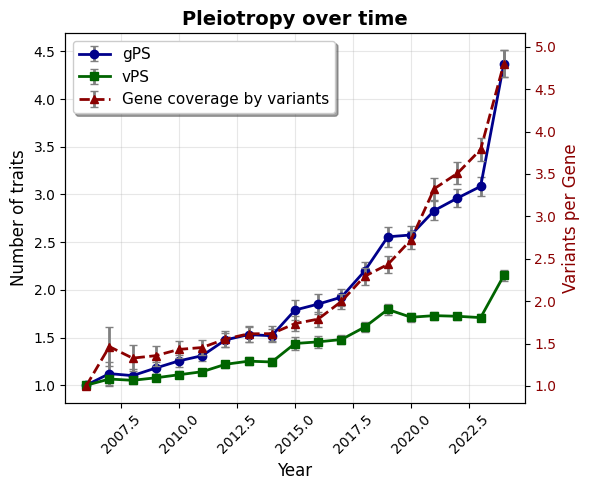

In [36]:
# Create the combined plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot pleiotropy scores on left y-axis
ax1.errorbar(
    stats_gene_pleiotropy["year"],
    stats_gene_pleiotropy["mean"],
    yerr=stats_gene_pleiotropy["se"] * 1.96,
    fmt="o-",
    linewidth=2,
    markersize=6,
    color="darkblue",
    ecolor="gray",
    capsize=3,
    label="gPS",
)

ax1.errorbar(
    stats_variant_pleiotropy["year"],
    stats_variant_pleiotropy["mean"],
    yerr=stats_variant_pleiotropy["se"] * 1.96,
    fmt="s-",
    linewidth=2,
    markersize=6,
    color="darkgreen",
    ecolor="gray",
    capsize=3,
    label="vPS",
)

# Left y-axis styling
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Number of traits", fontsize=12, color="black")
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=45)

# Create second y-axis for gene coverage
ax2 = ax1.twinx()
ax2.errorbar(
    stats_gene_coverage["year"],
    stats_gene_coverage["mean"],
    yerr=stats_gene_coverage["se"] * 1.96,
    fmt="^--",
    linewidth=2,
    markersize=6,
    color="darkred",
    ecolor="gray",
    capsize=3,
    label="Gene coverage by variants",
)

# Right y-axis styling
ax2.set_ylabel("Variants per Gene", fontsize=12, color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, frameon=True, fancybox=True, shadow=True, loc="upper left")

plt.title("Pleiotropy over time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
